In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [6]:
df = pd.read_csv(r"C:\Users\ADMIN\Downloads\flood.csv")

In [7]:
df.head()

,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,3,8,6,6,4,4,6,2,3,2,...,10,7,4,2,3,4,3,2,6,0.450
1,8,4,5,7,7,9,1,5,5,4,...,9,2,6,2,1,1,9,1,3,0.475
2,3,10,4,1,7,5,4,7,4,9,...,7,4,4,8,6,1,8,3,6,0.515
3,4,4,2,7,3,4,1,4,6,4,...,4,2,6,6,8,8,6,6,10,0.520
4,3,7,5,2,5,8,5,2,7,5,...,7,6,5,3,3,4,4,3,4,0.475


In [8]:
df.shape

(50000, 21)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   MonsoonIntensity                 50000 non-null  int64  
 1   TopographyDrainage               50000 non-null  int64  
 2   RiverManagement                  50000 non-null  int64  
 3   Deforestation                    50000 non-null  int64  
 4   Urbanization                     50000 non-null  int64  
 5   ClimateChange                    50000 non-null  int64  
 6   DamsQuality                      50000 non-null  int64  
 7   Siltation                        50000 non-null  int64  
 8   AgriculturalPractices            50000 non-null  int64  
 9   Encroachments                    50000 non-null  int64  
 10  IneffectiveDisasterPreparedness  50000 non-null  int64  
 11  DrainageSystems                  50000 non-null  int64  
 12  CoastalVulnerabili

In [10]:
print(df.isnull().sum())

MonsoonIntensity                   0
TopographyDrainage                 0
RiverManagement                    0
Deforestation                      0
Urbanization                       0
ClimateChange                      0
DamsQuality                        0
Siltation                          0
AgriculturalPractices              0
Encroachments                      0
IneffectiveDisasterPreparedness    0
DrainageSystems                    0
CoastalVulnerability               0
Landslides                         0
Watersheds                         0
DeterioratingInfrastructure        0
PopulationScore                    0
WetlandLoss                        0
InadequatePlanning                 0
PoliticalFactors                   0
FloodProbability                   0
dtype: int64


In [11]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [12]:
print(df.describe())

       MonsoonIntensity  TopographyDrainage  RiverManagement  Deforestation  \
count      50000.000000        50000.000000      50000.00000   50000.000000   
mean           4.991480            4.984100          5.01594       5.008480   
std            2.236834            2.246488          2.23131       2.222743   
min            0.000000            0.000000          0.00000       0.000000   
25%            3.000000            3.000000          3.00000       3.000000   
50%            5.000000            5.000000          5.00000       5.000000   
75%            6.000000            6.000000          6.00000       6.000000   
max           16.000000           18.000000         16.00000      17.000000   

       Urbanization  ClimateChange  DamsQuality     Siltation  \
count  50000.000000   50000.000000  50000.00000  50000.000000   
mean       4.989060       4.988340      5.01536      4.988600   
std        2.243159       2.226761      2.24500      2.232642   
min        0.000000       0.

In [13]:
df['FloodRisk'] = np.where(
    df['FloodProbability'] >= 0.50,
    1,
    0
)

In [14]:
print(df['FloodRisk'].value_counts())

FloodRisk
1    25513
0    24487
Name: count, dtype: int64


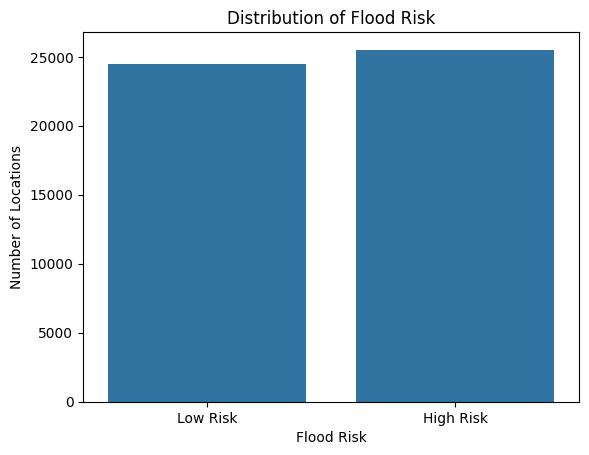

In [15]:
sns.countplot(x='FloodRisk', data=df)

plt.title("Distribution of Flood Risk")
plt.xlabel("Flood Risk")
plt.ylabel("Number of Locations")
plt.xticks([0, 1], ['Low Risk', 'High Risk'])
plt.show()

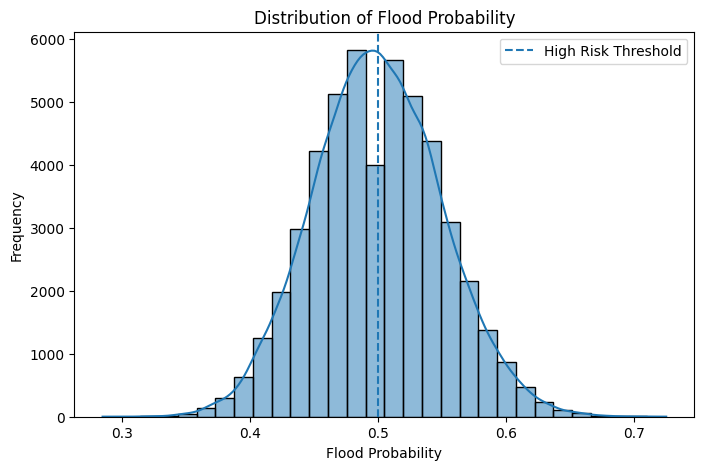

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['FloodProbability'],
    bins=30,
    kde=True
)

plt.axvline(
    0.5,
    linestyle='--',
    label='High Risk Threshold'
)

plt.title("Distribution of Flood Probability")
plt.xlabel("Flood Probability")
plt.ylabel("Frequency")
plt.legend()
plt.show()

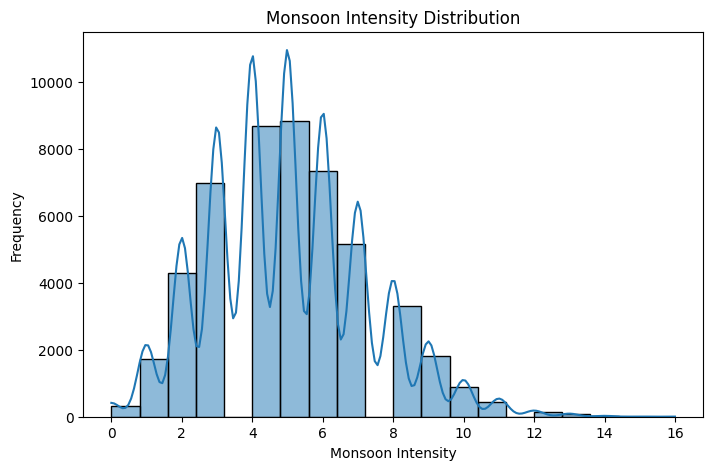

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['MonsoonIntensity'],
    bins=20,
    kde=True
)

plt.title("Monsoon Intensity Distribution")
plt.xlabel("Monsoon Intensity")
plt.ylabel("Frequency")

plt.show()

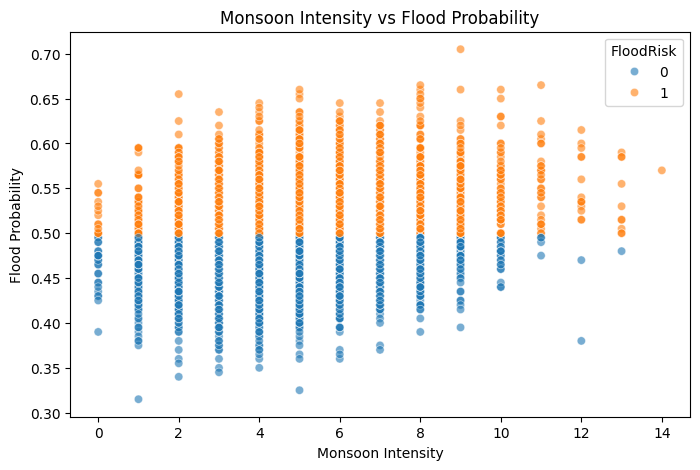

In [18]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df.sample(5000, random_state=42),
    x='MonsoonIntensity',
    y='FloodProbability',
    hue='FloodRisk',
    alpha=0.6
)

plt.title("Monsoon Intensity vs Flood Probability")
plt.xlabel("Monsoon Intensity")
plt.ylabel("Flood Probability")

plt.show()

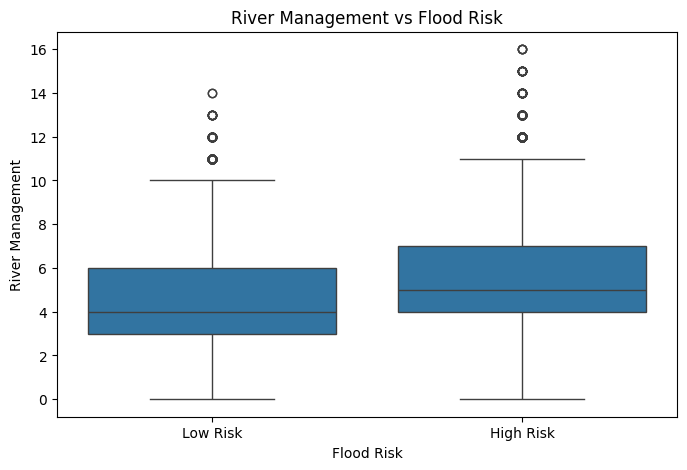

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='FloodRisk',
    y='RiverManagement'
)

plt.title("River Management vs Flood Risk")
plt.xlabel("Flood Risk")
plt.ylabel("River Management")

plt.xticks(
    [0,1],
    ['Low Risk', 'High Risk']
)

plt.show()

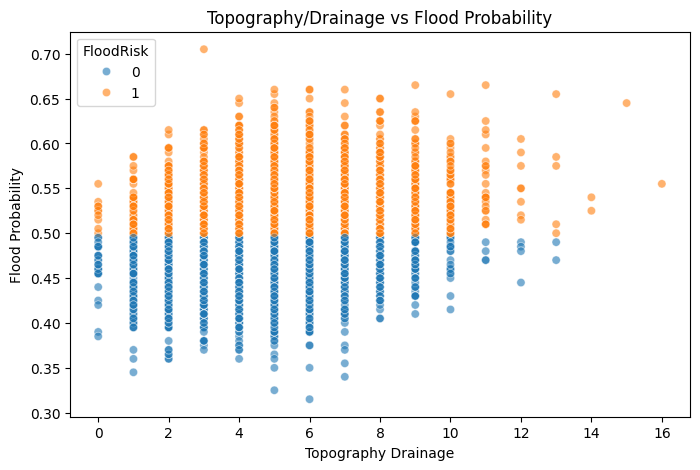

In [20]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df.sample(5000, random_state=42),
    x='TopographyDrainage',
    y='FloodProbability',
    hue='FloodRisk',
    alpha=0.6
)

plt.title("Topography/Drainage vs Flood Probability")
plt.xlabel("Topography Drainage")
plt.ylabel("Flood Probability")

plt.show()

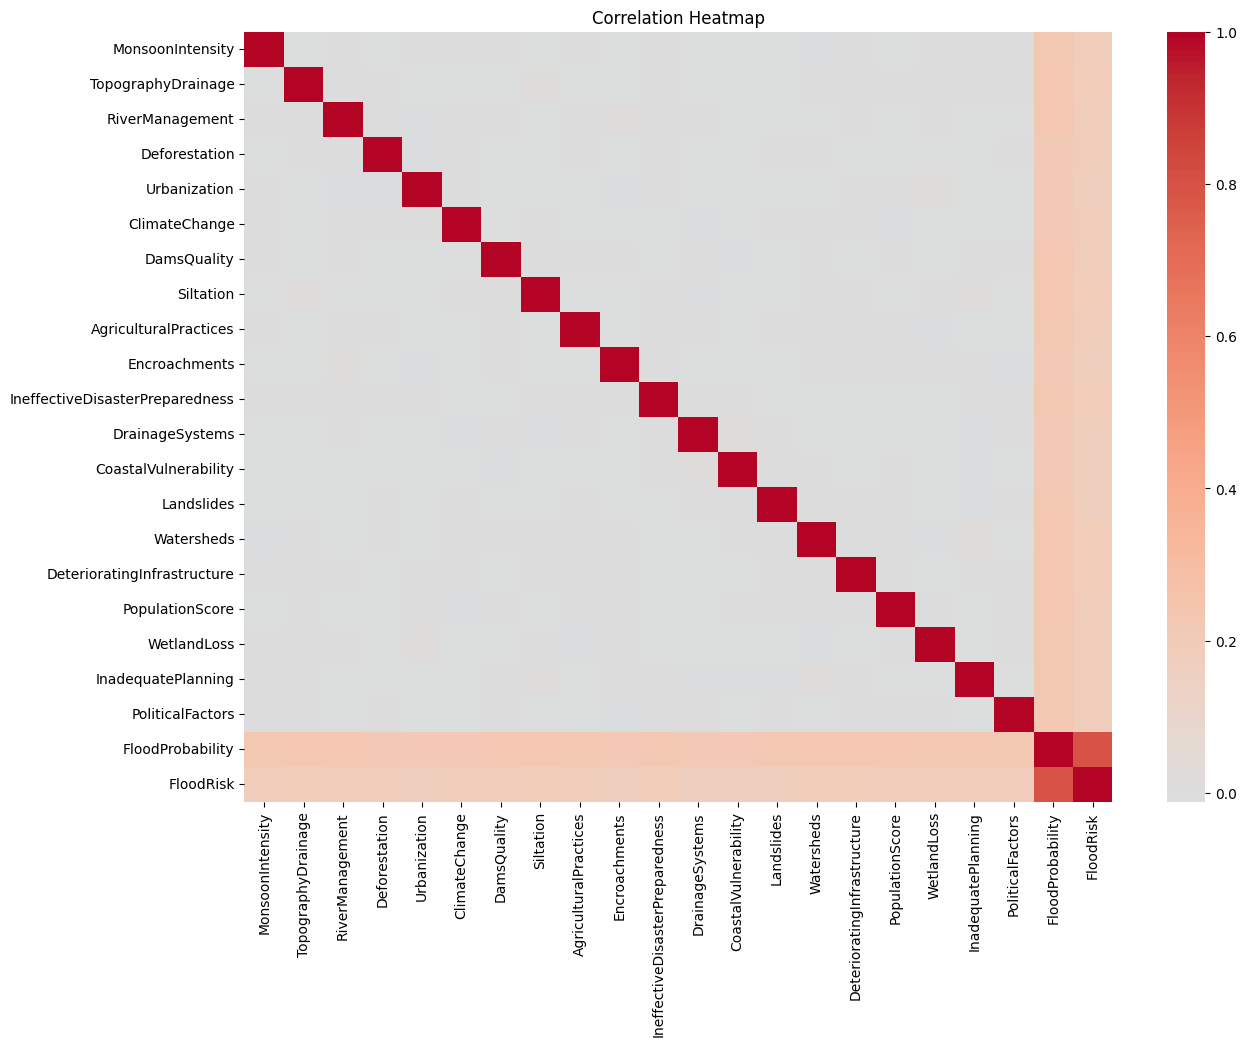

In [19]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0
)

plt.title("Correlation Heatmap")

plt.show()

In [20]:
print(
    df.corr(numeric_only=True)['FloodProbability']
    .sort_values(ascending=False)
)

FloodProbability                   1.000000
FloodRisk                          0.797795
DeterioratingInfrastructure        0.229444
TopographyDrainage                 0.229414
RiverManagement                    0.228917
Watersheds                         0.228152
DamsQuality                        0.227467
PopulationScore                    0.226928
Siltation                          0.226544
IneffectiveDisasterPreparedness    0.225126
PoliticalFactors                   0.225009
MonsoonIntensity                   0.224081
WetlandLoss                        0.223732
InadequatePlanning                 0.223329
Landslides                         0.222991
AgriculturalPractices              0.221846
ClimateChange                      0.220986
Urbanization                       0.220867
Deforestation                      0.220237
Encroachments                      0.218259
DrainageSystems                    0.217895
CoastalVulnerability               0.215187
Name: FloodProbability, dtype: f

In [21]:
risk_means = df.groupby('FloodRisk').mean(numeric_only=True)

print(risk_means.T)

FloodRisk                               0         1
MonsoonIntensity                 4.583738  5.382824
TopographyDrainage               4.560134  5.391016
RiverManagement                  4.609262  5.406263
Deforestation                    4.605995  5.394779
Urbanization                     4.590926  5.371183
ClimateChange                    4.584555  5.375887
DamsQuality                      4.599706  5.414299
Siltation                        4.569118  5.391212
AgriculturalPractices            4.603667  5.392388
Encroachments                    4.610569  5.386274
IneffectiveDisasterPreparedness  4.581982  5.411045
DrainageSystems                  4.612652  5.383648
CoastalVulnerability             4.607914  5.376161
Landslides                       4.589129  5.363423
Watersheds                       4.550986  5.391408
DeterioratingInfrastructure      4.572508  5.387175
PopulationScore                  4.573039  5.380355
WetlandLoss                      4.605627  5.388547
InadequatePl

In [22]:
X = df.drop(
    columns=['FloodProbability', 'FloodRisk']
)

y = df['FloodRisk']

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [25]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    max_depth=12,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are c

In [26]:
y_pred = model.predict(X_test)

y_probability = model.predict_proba(X_test)[:, 1]

In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

In [28]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_probability))

Accuracy: 0.6849
Precision: 0.7052144659377628
Recall: 0.6572604350382129
F1 Score: 0.680393549041485
ROC-AUC: 0.7483924878361382


In [29]:
y_pred_risk = (
    y_probability >= 0.35
).astype(int)

In [30]:
print(
    classification_report(
        y_test,
        y_pred_risk,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.7070    0.6200    0.6606      4897
           1     0.6739    0.7535    0.7114      5103

    accuracy                         0.6881     10000
   macro avg     0.6904    0.6867    0.6860     10000
weighted avg     0.6901    0.6881    0.6866     10000



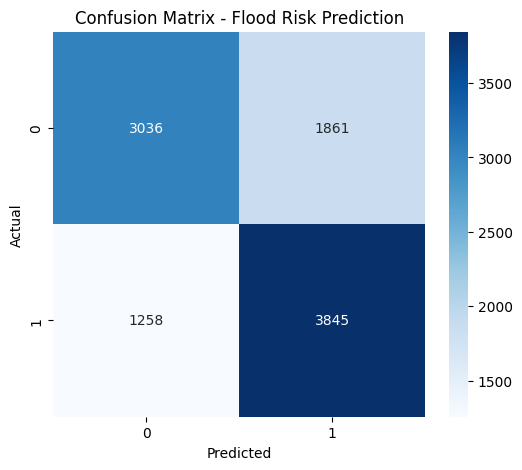

In [31]:
cm = confusion_matrix(
    y_test,
    y_pred_risk
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix - Flood Risk Prediction")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [32]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)

DamsQuality                        0.062170
IneffectiveDisasterPreparedness    0.062036
Urbanization                       0.056559
Siltation                          0.055684
ClimateChange                      0.054744
Deforestation                      0.054326
TopographyDrainage                 0.053281
PoliticalFactors                   0.053109
CoastalVulnerability               0.050328
Watersheds                         0.049901
MonsoonIntensity                   0.049190
AgriculturalPractices              0.049128
PopulationScore                    0.047936
Landslides                         0.046924
Encroachments                      0.046194
DeterioratingInfrastructure        0.045642
RiverManagement                    0.044213
WetlandLoss                        0.043474
InadequatePlanning                 0.037729
DrainageSystems                    0.037434
dtype: float64


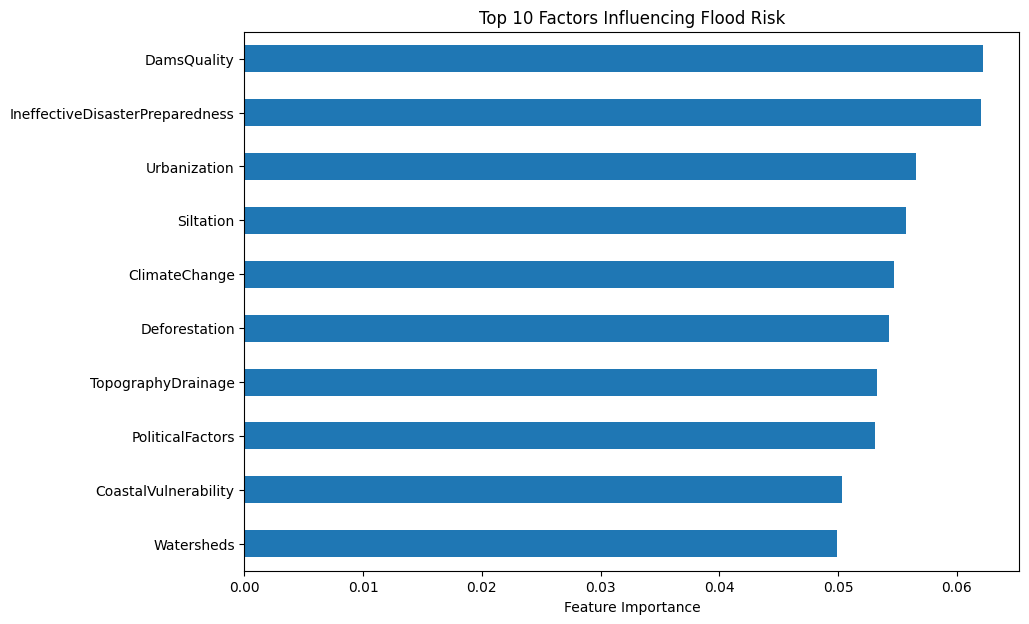

In [33]:
plt.figure(figsize=(10,7))

importance.head(10).sort_values().plot(
    kind='barh'
)

plt.title("Top 10 Factors Influencing Flood Risk")
plt.xlabel("Feature Importance")

plt.show()

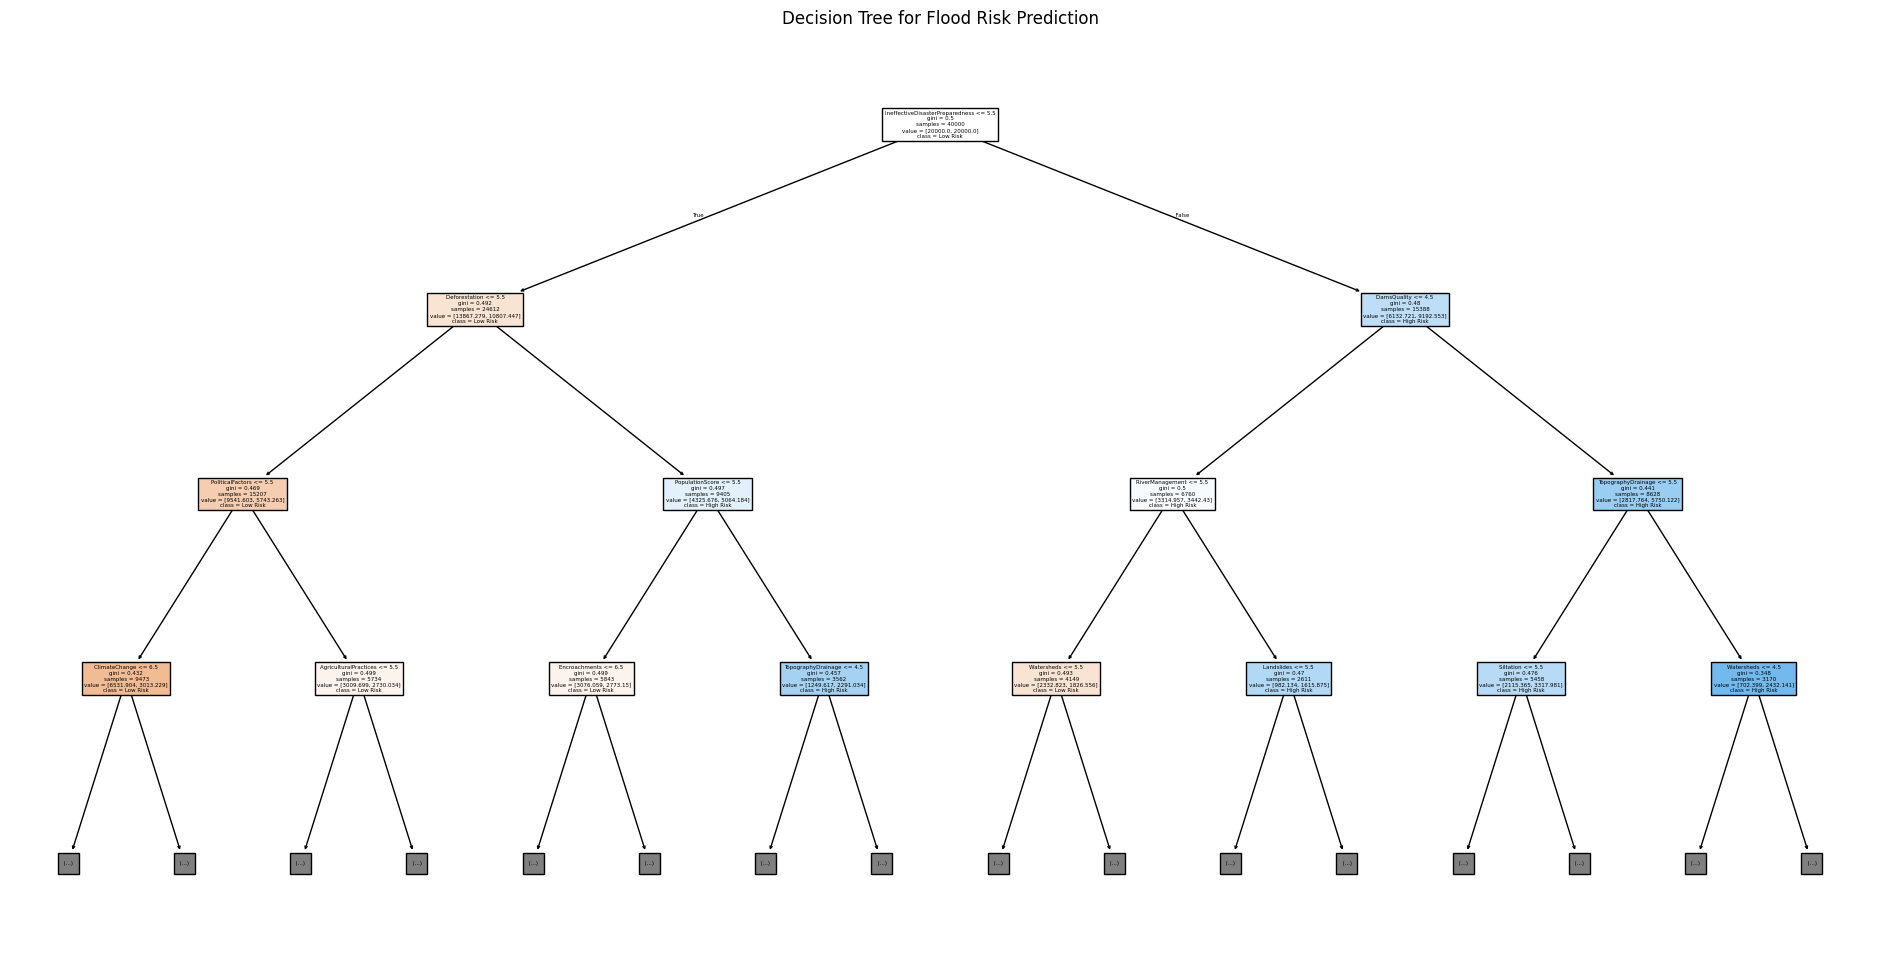

In [35]:
from sklearn.tree import plot_tree

plt.figure(figsize=(24,12))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=['Low Risk', 'High Risk'],
    filled=True,
    max_depth=3
)

plt.title("Decision Tree for Flood Risk Prediction")

plt.show()